In [1]:
# spaCy EDA - Modern NLP with spaCy
# This notebook demonstrates spaCy's capabilities for NLP tasks

import spacy
from spacy import displacy
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Load the English model (download with: python -m spacy download en_core_web_sm)
nlp = spacy.load('en_core_web_sm')


### 1. BASIC TEXT PROCESSING AND TOKENIZATION

In [2]:
sample_text = """
Natural language processing (NLP) is a subfield of linguistics, computer science,
and artificial intelligence concerned with the interactions between computers and
human language. NLP is used to apply machine learning algorithms to text and speech.
"""

print("=" * 70)
print("1. TOKENIZATION AND TEXT PROCESSING")
print("=" * 70)

doc = nlp(sample_text)

# Basic tokenization
print(f"\nTotal tokens: {len(doc)}")
print(f"\nFirst 15 tokens:")
print("{:<15} {:<10} {:<10}".format("Token", "POS", "Lemma"))
print("-" * 35)
for token in list(doc)[:15]:
    print("{:<15} {:<10} {:<10}".format(token.text, token.pos_, token.lemma_))


1. TOKENIZATION AND TEXT PROCESSING

Total tokens: 45

First 15 tokens:
Token           POS        Lemma     
-----------------------------------

               SPACE      
         
Natural         ADJ        natural   
language        NOUN       language  
processing      NOUN       processing
(               PUNCT      (         
NLP             PROPN      NLP       
)               PUNCT      )         
is              AUX        be        
a               DET        a         
subfield        NOUN       subfield  
of              ADP        of        
linguistics     NOUN       linguistic
,               PUNCT      ,         
computer        NOUN       computer  
science         NOUN       science   


### 2. PART-OF-SPEECH (POS) TAGGING

In [3]:
print("\n" + "=" * 70)
print("2. PART-OF-SPEECH (POS) TAGGING - DETAILED")
print("=" * 70)

pos_counts = Counter([token.pos_ for token in doc])
print(f"\nPOS Distribution:")
pos_df = pd.DataFrame(pos_counts.most_common(), columns=['POS', 'Count'])
print(pos_df.to_string(index=False))


2. PART-OF-SPEECH (POS) TAGGING - DETAILED

POS Distribution:
  POS  Count
 NOUN     15
PUNCT      6
SPACE      4
  ADJ      3
  ADP      3
CCONJ      3
 VERB      3
PROPN      2
  AUX      2
  DET      2
 PART      2


### 3. NAMED ENTITY RECOGNITION (NER)

In [4]:
print("\n" + "=" * 70)
print("3. NAMED ENTITY RECOGNITION (NER)")
print("=" * 70)

print(f"\nNamed Entities found:")
print("{:<25} {:<15} {:<30}".format("Entity", "Label", "Description"))
print("-" * 70)

entity_labels = {
    'PERSON': 'People',
    'ORG': 'Organizations',
    'GPE': 'Geopolitical entities',
    'DATE': 'Dates',
    'PRODUCT': 'Products',
    'EVENT': 'Events'
}

for ent in doc.ents:
    desc = entity_labels.get(ent.label_, 'Other')
    print("{:<25} {:<15} {:<30}".format(ent.text, ent.label_, desc))

# Entity type distribution
entity_counts = Counter([ent.label_ for ent in doc.ents])
print(f"\nEntity Distribution:")
entity_df = pd.DataFrame(entity_counts.most_common(), columns=['Entity Type', 'Count'])
print(entity_df.to_string(index=False))



3. NAMED ENTITY RECOGNITION (NER)

Named Entities found:
Entity                    Label           Description                   
----------------------------------------------------------------------
NLP                       ORG             Organizations                 
NLP                       ORG             Organizations                 

Entity Distribution:
Entity Type  Count
        ORG      2


### 4. STOP WORDS

In [5]:
print("\n" + "=" * 70)
print("4. STOP WORDS ANALYSIS")
print("=" * 70)

stop_words = set(spacy.lang.en.STOP_WORDS)
print(f"\nTotal stop words in English: {len(stop_words)}")

tokens = [token.text.lower() for token in doc if token.is_alpha]
stopped = [t for t in tokens if t not in stop_words]
not_stopped = [t for t in tokens if t in stop_words]

print(f"Tokens in text: {len(tokens)}")
print(f"Content words (non-stop): {len(stopped)}")
print(f"Stop words: {len(not_stopped)}")
print(f"\nStop word examples in text: {not_stopped[:10]}")



4. STOP WORDS ANALYSIS

Total stop words in English: 326
Tokens in text: 35
Content words (non-stop): 22
Stop words: 13

Stop word examples in text: ['is', 'a', 'of', 'and', 'with', 'the', 'between', 'and', 'is', 'used']


### 5. LEMMATIZATION

In [6]:
print("\n" + "=" * 70)
print("5. LEMMATIZATION")
print("=" * 70)

lemma_text = "running runs ran designed manufacturing designed devices"
lemma_doc = nlp(lemma_text)

print(f"\nLemmatization for: '{lemma_text}'")
print("{:<15} {:<15}".format("Original", "Lemma"))
print("-" * 30)
for token in lemma_doc:
    if token.is_alpha:
        print("{:<15} {:<15}".format(token.text, token.lemma_))



5. LEMMATIZATION

Lemmatization for: 'running runs ran designed manufacturing designed devices'
Original        Lemma          
------------------------------
running         run            
runs            run            
ran             ran            
designed        design         
manufacturing   manufacture    
designed        design         
devices         device         


### 6. DEPENDENCY PARSING

In [7]:
print("\n" + "=" * 70)
print("6. DEPENDENCY PARSING")
print("=" * 70)

sentence = "Steve Jobs founded Apple Inc."
sent_doc = nlp(sentence)

print(f"\nDependency relations for: '{sentence}'")
print("{:<15} {:<15} {:<15}".format("Token", "Dependency", "Head"))
print("-" * 45)
for token in sent_doc:
    print("{:<15} {:<15} {:<15}".format(token.text, token.dep_, token.head.text))



6. DEPENDENCY PARSING

Dependency relations for: 'Steve Jobs founded Apple Inc.'
Token           Dependency      Head           
---------------------------------------------
Steve           compound        Jobs           
Jobs            nsubj           founded        
founded         ROOT            founded        
Apple           compound        Inc.           
Inc.            dobj            founded        


### 7. NOUN CHUNKS

In [8]:

print("\n" + "=" * 70)
print("7. NOUN CHUNKS (BASE NOUN PHRASES)")
print("=" * 70)

print(f"\nNoun chunks in the text:")
noun_chunks = list(doc.noun_chunks)
for i, chunk in enumerate(noun_chunks, 1):
    print(f"  {i}. {chunk.text}")



7. NOUN CHUNKS (BASE NOUN PHRASES)

Noun chunks in the text:
  1. 
Natural language processing
  2. NLP
  3. a subfield
  4. linguistics
  5. computer science
  6. artificial intelligence
  7. the interactions
  8. computers
  9. human language
  10. NLP
  11. machine learning algorithms
  12. text
  13. speech


### 8. SENTENCE SEGMENTATION

In [9]:
print("\n" + "=" * 70)
print("8. SENTENCE SEGMENTATION")
print("=" * 70)

print(f"\nTotal sentences: {len(list(doc.sents))}")
print("\nSentences:")
for i, sent in enumerate(doc.sents, 1):
    print(f"  {i}. {sent.text[:70]}...")



8. SENTENCE SEGMENTATION

Total sentences: 2

Sentences:
  1. 
Natural language processing (NLP) is a subfield of linguistics, compu...
  2. NLP is used to apply machine learning algorithms to text and speech.
...


### 9. TOKEN ATTRIBUTES

In [10]:
print("\n" + "=" * 70)
print("9. DETAILED TOKEN ATTRIBUTES")
print("=" * 70)

sample_sent = "Apple released the iPhone 12 on November 10, 2020."
attr_doc = nlp(sample_sent)

print(f"\nDetailed attributes for: '{sample_sent}'")
print("{:<12} {:<10} {:<10} {:<8} {:<8}".format("Token", "POS", "Tag", "Lemma", "Stop?"))
print("-" * 48)
for token in attr_doc:
    is_stop = "Yes" if token.is_stop else "No"
    print("{:<12} {:<10} {:<10} {:<8} {:<8}".format(token.text, token.pos_, token.tag_, token.lemma_, is_stop))


9. DETAILED TOKEN ATTRIBUTES

Detailed attributes for: 'Apple released the iPhone 12 on November 10, 2020.'
Token        POS        Tag        Lemma    Stop?   
------------------------------------------------
Apple        PROPN      NNP        Apple    No      
released     VERB       VBD        release  No      
the          DET        DT         the      Yes     
iPhone       PROPN      NNP        iPhone   No      
12           NUM        CD         12       No      
on           ADP        IN         on       Yes     
November     PROPN      NNP        November No      
10           NUM        CD         10       No      
,            PUNCT      ,          ,        No      
2020         NUM        CD         2020     No      
.            PUNCT      .          .        No      


### 10. WORD FREQUENCY ANALYSIS

In [11]:
print("\n" + "=" * 70)
print("10. WORD FREQUENCY ANALYSIS")
print("=" * 70)

# Filter: lowercase, alphabetic, non-stop words
filtered_tokens = [token.text.lower() for token in doc
                   if token.is_alpha and not token.is_stop]
word_freq = Counter(filtered_tokens)

print(f"\nTop 15 most frequent content words:")
print("{:<15} {:<10}".format("Word", "Frequency"))
print("-" * 25)
for word, count in word_freq.most_common(15):
    print("{:<15} {:<10}".format(word, count))


10. WORD FREQUENCY ANALYSIS

Top 15 most frequent content words:
Word            Frequency 
-------------------------
language        2         
nlp             2         
natural         1         
processing      1         
subfield        1         
linguistics     1         
computer        1         
science         1         
artificial      1         
intelligence    1         
concerned       1         
interactions    1         
computers       1         
human           1         
apply           1         


### 11. VISUALIZATION


11. VISUALIZATION


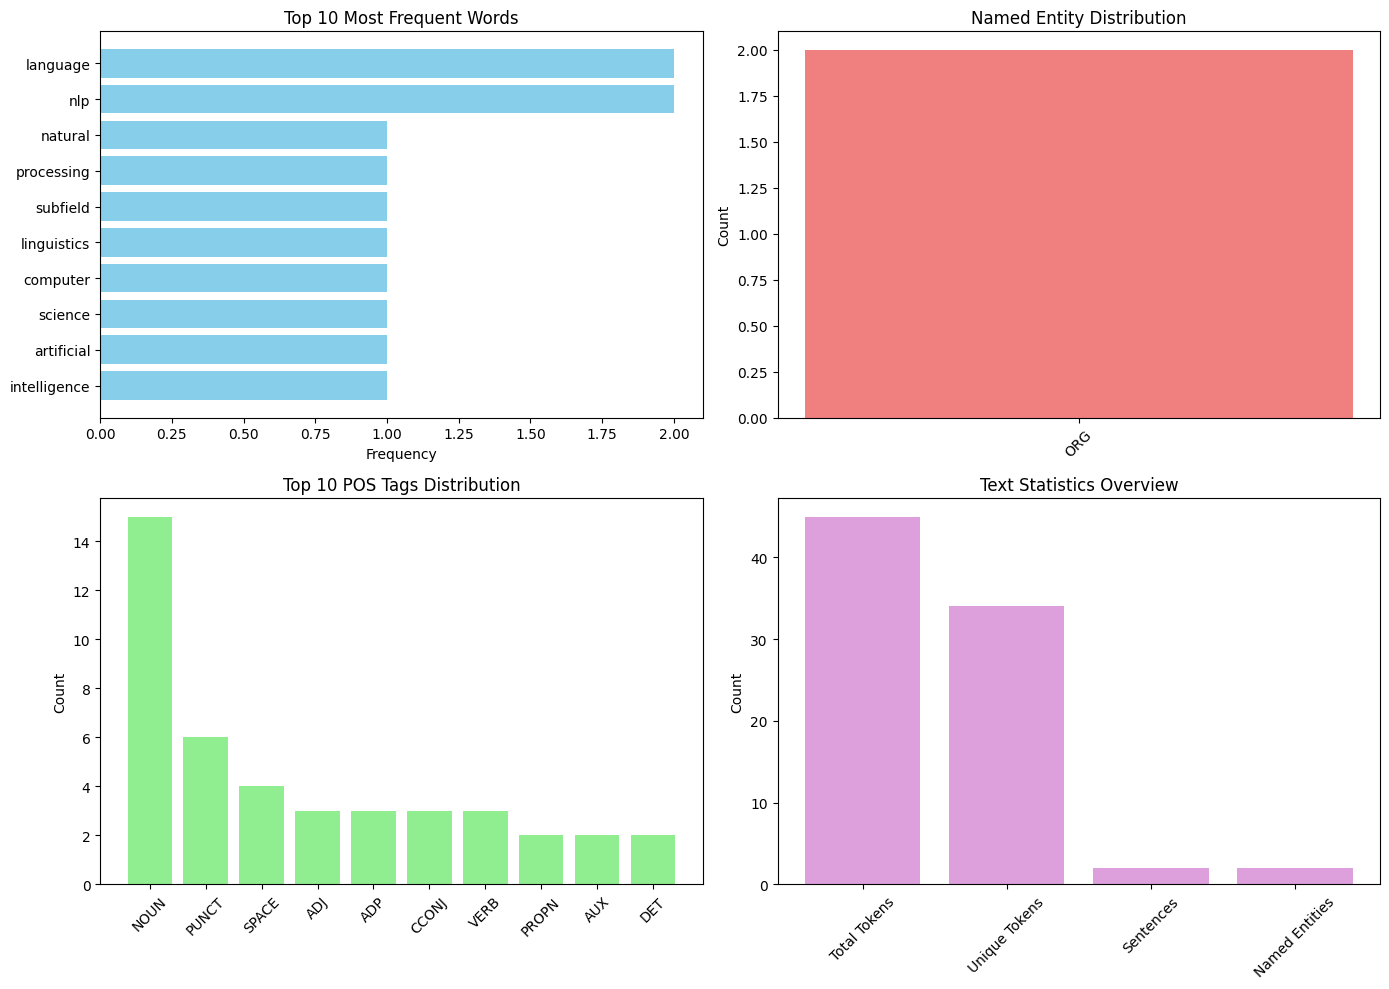

In [12]:
print("\n" + "=" * 70)
print("11. VISUALIZATION")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Word frequency
words, counts = zip(*word_freq.most_common(10))
axes[0, 0].barh(words, counts, color='skyblue')
axes[0, 0].set_xlabel('Frequency')
axes[0, 0].set_title('Top 10 Most Frequent Words')
axes[0, 0].invert_yaxis()

# Plot 2: Entity distribution
entity_types, entity_counts_list = zip(*entity_df.values)
axes[0, 1].bar(entity_types, entity_counts_list, color='lightcoral')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Named Entity Distribution')
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: POS distribution
pos_types, pos_counts_list = zip(*pos_df.head(10).values)
axes[1, 0].bar(pos_types, pos_counts_list, color='lightgreen')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Top 10 POS Tags Distribution')
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Token statistics
stats = ['Total Tokens', 'Unique Tokens', 'Sentences', 'Named Entities']
values = [len(doc), len(set([t.text for t in doc])), len(list(doc.sents)), len(doc.ents)]
axes[1, 1].bar(stats, values, color='plum')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Text Statistics Overview')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 12. SUMMARY STATISTICS

In [13]:
print("\n" + "=" * 70)
print("12. SUMMARY STATISTICS")
print("=" * 70)

summary_data = {
    'Metric': [
        'Total Tokens',
        'Unique Tokens',
        'Total Sentences',
        'Named Entities',
        'Noun Chunks',
        'Average Tokens per Sentence',
        'Unique Stop Words',
        'Unique Content Words'
    ],
    'Value': [
        len(doc),
        len(set([t.text for t in doc])),
        len(list(doc.sents)),
        len(doc.ents),
        len(noun_chunks),
        f"{len(doc) / len(list(doc.sents)):.2f}",
        len(not_stopped),
        len(stopped)
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n", summary_df.to_string(index=False))


12. SUMMARY STATISTICS

                      Metric Value
               Total Tokens    45
              Unique Tokens    34
            Total Sentences     2
             Named Entities     2
                Noun Chunks    13
Average Tokens per Sentence 22.50
          Unique Stop Words    13
       Unique Content Words    22
